In [57]:
# File paths
train_path = r"C:\Users\ganes\Downloads\house-prices-advanced-regression-techniques\train.csv"
test_path = r"C:\Users\ganes\Downloads\house-prices-advanced-regression-techniques\test.csv"
sample_submission_path = r"C:\Users\ganes\Downloads\house-prices-advanced-regression-techniques\sample_submission.csv"
data_description_path = r"C:\Users\ganes\Downloads\house-prices-advanced-regression-techniques\data_description.txt"

# Load CSV files
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
sample_submission_df = pd.read_csv(sample_submission_path)

# Load description
with open(data_description_path, "r") as f:
    data_description = f.read()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_submission_df.shape)


Train shape: (1460, 81)
Test shape: (1459, 80)
Sample submission shape: (1459, 2)


In [53]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor



In [56]:
train_df.head()
train_df.info()
train_df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


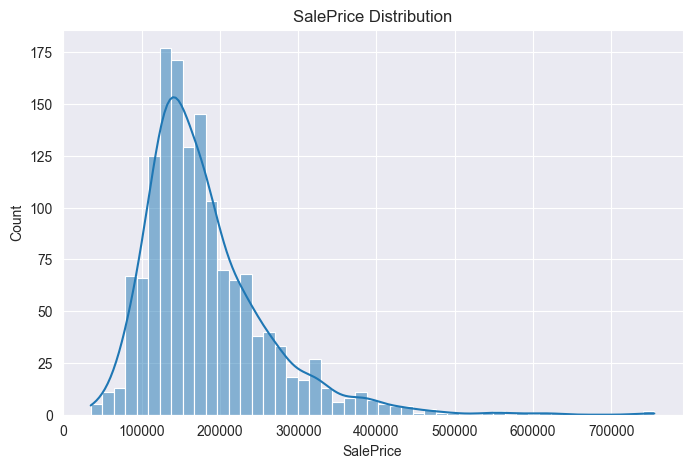

In [55]:
plt.figure(figsize=(8,5))
sns.histplot(train_df['SalePrice'], kde=True)
plt.title("SalePrice Distribution")
plt.show()

In [59]:
missing_values = train_df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [60]:
train_ID = train_df['Id']
test_ID = test_df['Id']

y = train_df['SalePrice']
train_df = train_df.drop(['Id', 'SalePrice'], axis=1)
test_df = test_df.drop(['Id'], axis=1)

all_data = pd.concat([train_df, test_df], axis=0)
print(all_data.shape)

(2919, 79)


In [61]:
# Separate numeric and categorical columns (future-proof)
numeric_cols = all_data.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = all_data.select_dtypes(include=['object', 'string']).columns

# Fill missing values
for col in numeric_cols:
    all_data[col] = all_data[col].fillna(all_data[col].median())

for col in categorical_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

# Verify
print("Remaining missing values:")
print(all_data.isnull().sum().sort_values(ascending=False).head())



Remaining missing values:
MSSubClass     0
MSZoning       0
LotFrontage    0
LotArea        0
Street         0
dtype: int64


In [63]:
from sklearn.preprocessing import LabelEncoder

for col in all_data.columns:
    if all_data[col].dtype == 'object':
        le = LabelEncoder()
        all_data[col] = le.fit_transform(all_data[col].astype(str))

In [65]:
X = all_data[:len(y)]
X_test_final = all_data[len(y):]

In [66]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [68]:
# Separate numeric and categorical columns (future-proof)
numeric_cols = all_data.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = all_data.select_dtypes(include=['object', 'string']).columns

# Fill missing values
for col in numeric_cols:
    all_data[col] = all_data[col].fillna(all_data[col].median())

for col in categorical_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

# Verify
print("Remaining missing values:")
print(all_data.isnull().sum().sort_values(ascending=False).head())



Remaining missing values:
MSSubClass     0
MSZoning       0
LotFrontage    0
LotArea        0
Street         0
dtype: int64


In [69]:
label_encoder = LabelEncoder()

for col in all_data.columns:
    if all_data[col].dtype in ['object', 'string']:
        all_data[col] = label_encoder.fit_transform(all_data[col])

print("Encoding completed")

Encoding completed


In [70]:
X = all_data.iloc[:len(y)]
X_test_final = all_data.iloc[len(y):]

print("Train features shape:", X.shape)
print("Test features shape:", X_test_final.shape)

Train features shape: (1460, 79)
Test features shape: (1459, 79)


In [71]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (1168, 79)
X_val shape: (292, 79)


In [72]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_val)
rmse_lr = np.sqrt(mean_squared_error(y_val, y_pred_lr))

print("Linear Regression RMSE:", rmse_lr)

Linear Regression RMSE: 36717.30472677461


In [73]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))

print("Random Forest RMSE:", rmse_rf)

Random Forest RMSE: 28564.470775466638


In [74]:
rf.fit(X, y)

test_predictions = rf.predict(X_test_final)

print("Predictions generated!")
print("Number of predictions:", len(test_predictions))
print("First 10 predictions:", test_predictions[:10])
print("Min prediction:", test_predictions.min())
print("Max prediction:", test_predictions.max())

Predictions generated!
Number of predictions: 1459
First 10 predictions: [127908.085 155319.25  180231.95  180935.37  198306.48  183282.95
 167991.575 175007.32  182172.335 122246.5  ]
Min prediction: 55644.33
Max prediction: 530632.45


In [78]:
import pandas as pd

# Paths
test_path = r"C:\Users\ganes\Downloads\house-prices-advanced-regression-techniques\test.csv"
submission_path = r"C:\Users\ganes\Downloads\house-prices-advanced-regression-techniques\submission_v2.csv"

# Load test data
test_df = pd.read_csv(test_path)

# Create submission
submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": test_predictions
})

# Save (no overwrite, no delete)
submission.to_csv(submission_path, index=False)

print("Submission file created successfully!")

Submission file created successfully!
